# Big Mart Sales Prediction — Enhanced (Capstone-level)

**Contents:** Data loading, full EDA with plots, preprocessing, feature engineering, model training (LinearRegression, RandomForest, XGBoost, Ridge, Lasso), evaluation, final predictions and export.

This notebook was generated and prepared programmatically. Run the cells sequentially.

In [4]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
sns.set(style='whitegrid')
%matplotlib inline

print("Working directory:", os.getcwd())
print("Files in current folder:", os.listdir())

Working directory: c:\Users\LAKSHMAN KUNTAMUKKAL\Downloads\BigMartSales
Files in current folder: ['Customer_Sale_Prediction_Enhanced.ipynb', 'test_.csv', 'train_ .csv', 'venv']


In [6]:
# Load datasets (adjust paths if needed)
train_path = 'train_.csv'
test_path  = 'test_.csv'

# Load datasets
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())
display(test.head())

Train shape: (8523, 12)
Test shape : (5681, 11)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [7]:
# Basic info and missing values
print('--- TRAIN INFO ---')
display(train.info())
print('\nMissing values in train:')
display(train.isnull().sum())

print('\n--- TEST INFO ---')
display(test.info())
print('\nMissing values in test:')
display(test.isnull().sum())

--- TRAIN INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


None


Missing values in train:


Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


--- TEST INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


None


Missing values in test:


Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

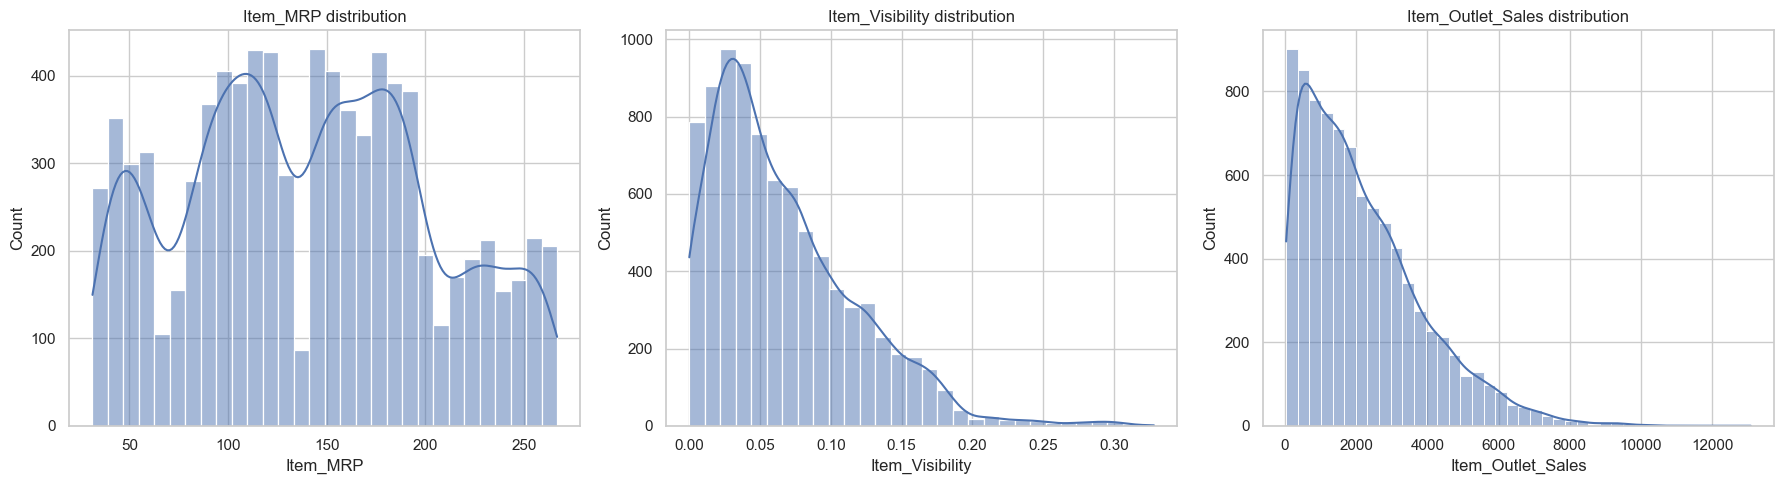

In [8]:
# EDA - distributions of key numeric variables
fig, axs = plt.subplots(1,3, figsize=(18,5))
sns.histplot(train['Item_MRP'], bins=30, kde=True, ax=axs[0])
axs[0].set_title('Item_MRP distribution')
sns.histplot(train['Item_Visibility'], bins=30, kde=True, ax=axs[1])
axs[1].set_title('Item_Visibility distribution')
sns.histplot(train['Item_Outlet_Sales'], bins=40, kde=True, ax=axs[2])
axs[2].set_title('Item_Outlet_Sales distribution')
plt.tight_layout()
plt.show()

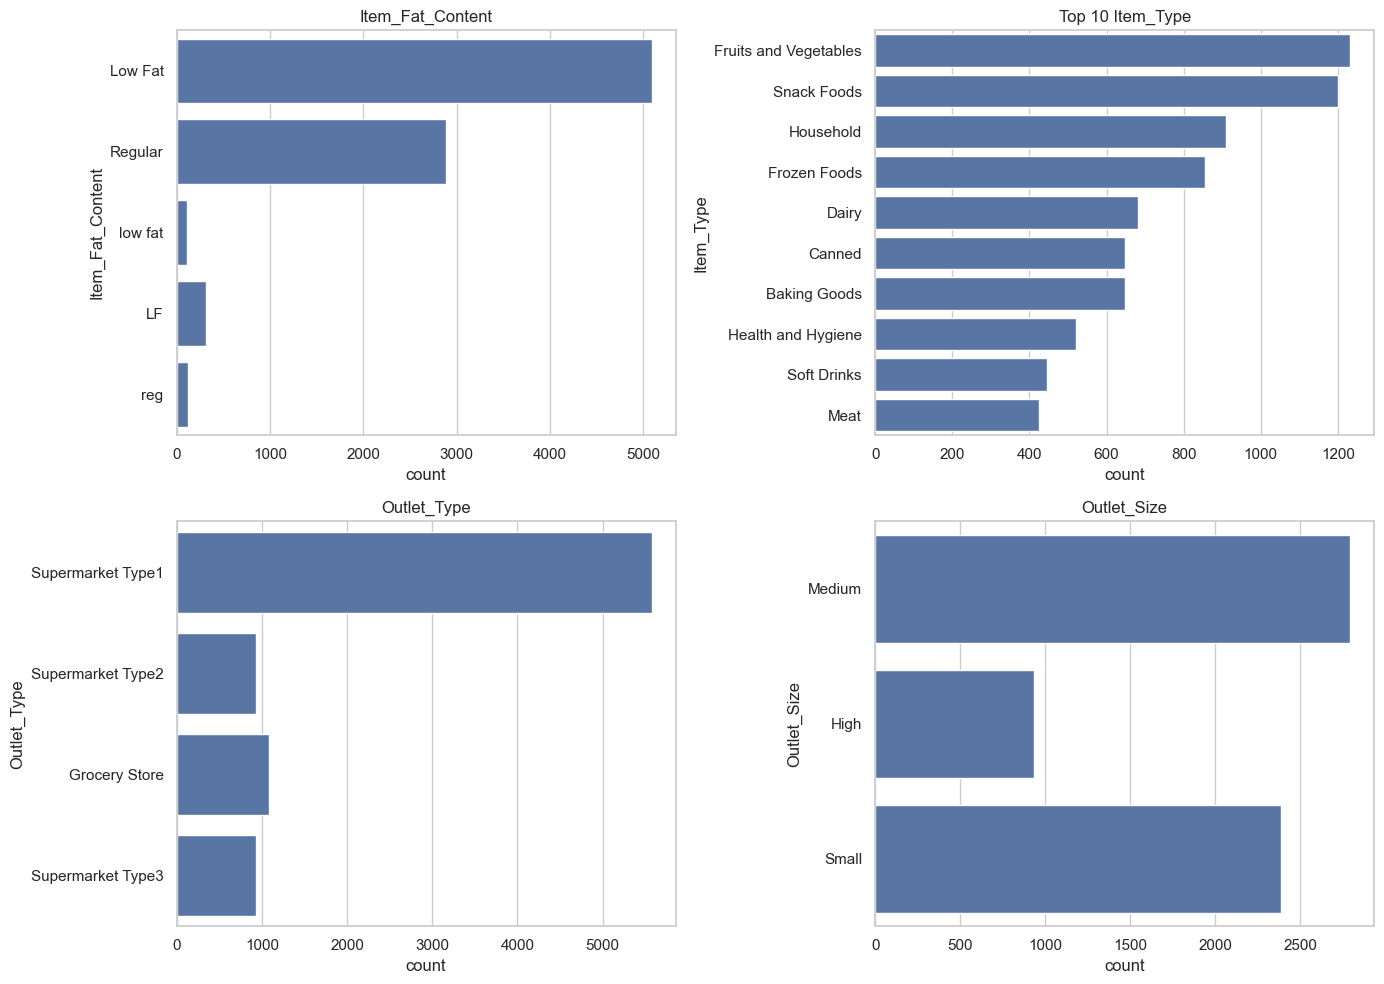

In [11]:
# Categorical counts (top categories)
fig, axs = plt.subplots(2,2, figsize=(14,10))
sns.countplot(y='Item_Fat_Content', data=train, ax=axs[0,0])
axs[0,0].set_title('Item_Fat_Content')

sns.countplot(y='Item_Type', data=train, order=train['Item_Type'].value_counts().index[:10], ax=axs[0,1])
axs[0,1].set_title('Top 10 Item_Type')

sns.countplot(y='Outlet_Type', data=train, ax=axs[1,0])
axs[1,0].set_title('Outlet_Type')

sns.countplot(y='Outlet_Size', data=train, ax=axs[1,1])
axs[1,1].set_title('Outlet_Size')

plt.tight_layout()
plt.show()

## Missing value handling
Strategy to impute missing values:
- `Item_Weight`: fill with training-set mean
- `Outlet_Size`: fill with training-set mode
- `Item_Visibility`: replace zeros with median of non-zero visibilities (zeros often mean missing)

We'll standardize `Item_Fat_Content` values as well.

In [12]:
# Standardize Item_Fat_Content
for df in (train, test):
    df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

# Impute Item_Weight with train mean
item_weight_mean = train['Item_Weight'].mean()
train['Item_Weight'] = train['Item_Weight'].fillna(item_weight_mean)
test['Item_Weight']  = test['Item_Weight'].fillna(item_weight_mean)

# Impute Outlet_Size with train mode
outlet_size_mode = train['Outlet_Size'].mode()[0]
train['Outlet_Size'] = train['Outlet_Size'].fillna(outlet_size_mode)
test['Outlet_Size']  = test['Outlet_Size'].fillna(outlet_size_mode)

# Replace Item_Visibility zeros with median of non-zero
vis_median = train.loc[train['Item_Visibility']>0, 'Item_Visibility'].median()
train['Item_Visibility'] = train['Item_Visibility'].replace(0, vis_median)
test['Item_Visibility']  = test['Item_Visibility'].replace(0, vis_median)

print('Missing values after imputation (train):')
display(train.isnull().sum())

Missing values after imputation (train):


Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

## Feature engineering
- Create `Outlet_Age`
- Extract simple `Item_Identifier` prefix as `Item_Category` (first 2 chars)
- Optionally create price-related features later

In [13]:
# Feature engineering
train['Outlet_Age'] = 2025 - train['Outlet_Establishment_Year']
test['Outlet_Age']  = 2025 - test['Outlet_Establishment_Year']

train['Item_Category'] = train['Item_Identifier'].str[:2]
test['Item_Category']  = test['Item_Identifier'].str[:2]

display(train[['Item_Identifier','Item_Category','Outlet_Establishment_Year','Outlet_Age']].head())

,Item_Identifier,Item_Category,Outlet_Establishment_Year,Outlet_Age
0,FDA15,FD,1999,26
1,DRC01,DR,2009,16
2,FDN15,FD,1999,26
3,FDX07,FD,1998,27
4,NCD19,NC,1987,38


C:\Users\LAKSHMAN KUNTAMUKKAL\AppData\Local\Temp\ipykernel_19616\1539191458.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mrp_sales = train.groupby('MRP_bin')['Item_Outlet_Sales'].median().reset_index()


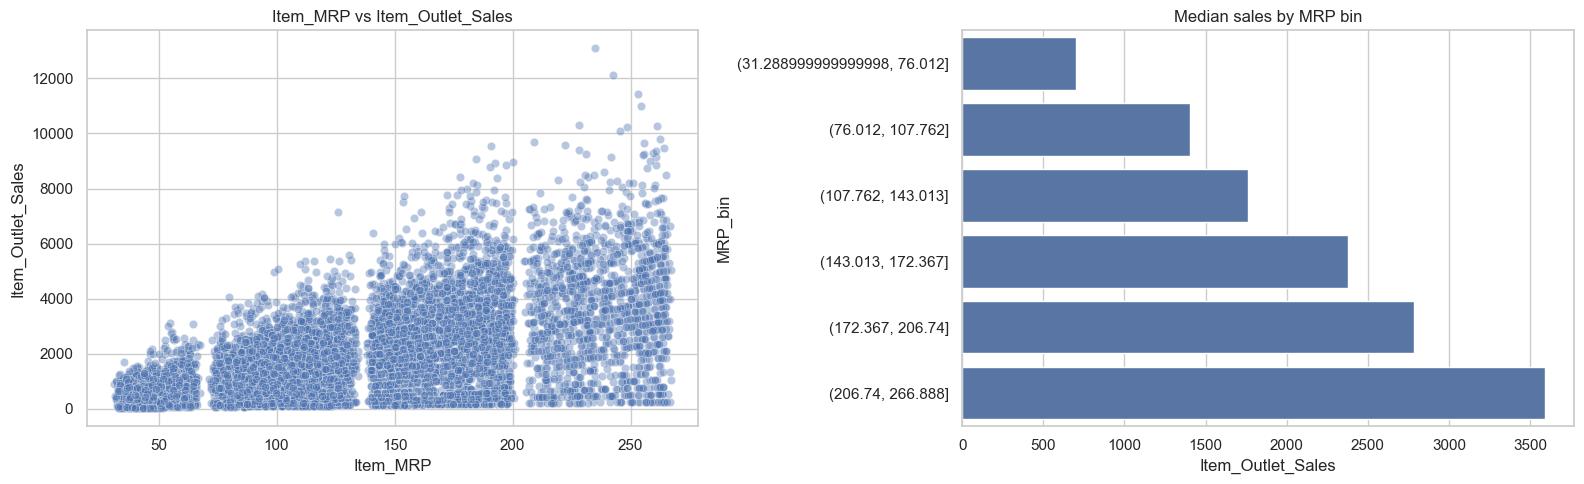

In [14]:
# EDA: Item_MRP vs Sales (boxplot and scatter)
fig, axs = plt.subplots(1,2, figsize=(16,5))
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=train, alpha=0.4, ax=axs[0])
axs[0].set_title('Item_MRP vs Item_Outlet_Sales')

# Bin MRP to see median sales per bin
train['MRP_bin'] = pd.qcut(train['Item_MRP'], 6, duplicates='drop')
mrp_sales = train.groupby('MRP_bin')['Item_Outlet_Sales'].median().reset_index()
sns.barplot(x='Item_Outlet_Sales', y='MRP_bin', data=mrp_sales, ax=axs[1])
axs[1].set_title('Median sales by MRP bin')
plt.tight_layout()
plt.show()

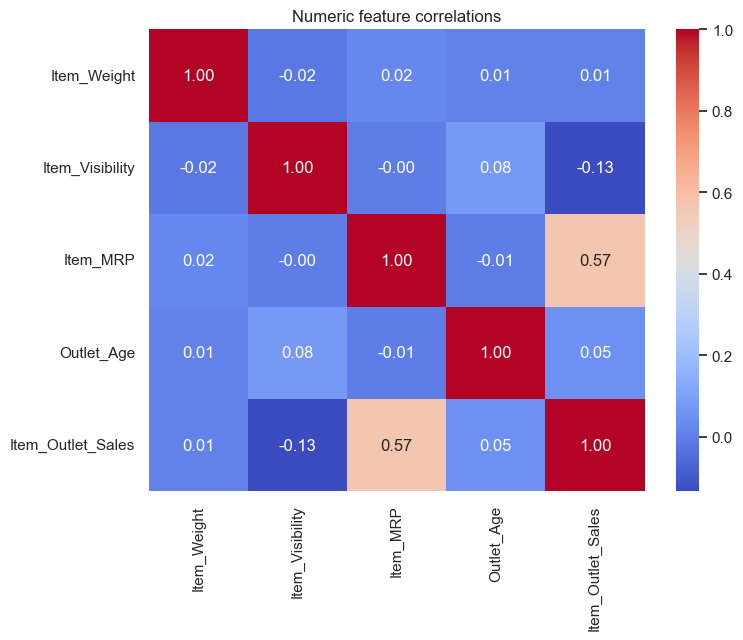

In [15]:
# Correlation heatmap of numeric features
num_cols = ['Item_Weight','Item_Visibility','Item_MRP','Outlet_Age','Item_Outlet_Sales']
plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric feature correlations')
plt.show()

## Prepare dataset for modeling
We'll combine train and test to ensure consistent one-hot encoding, then split back.

In [16]:
# Combine for one-hot encoding
train['is_train'] = 1
test['is_train'] = 0
test['Item_Outlet_Sales'] = np.nan  # placeholder

combined = pd.concat([train, test], sort=False).reset_index(drop=True)

# Columns to one-hot encode
cols_to_encode = ['Item_Fat_Content','Outlet_Size','Outlet_Location_Type','Outlet_Type','Item_Type','Item_Category','Outlet_Identifier']

combined = pd.get_dummies(combined, columns=cols_to_encode, drop_first=True)

# Create Outlet_Age already exists; drop establishment year if preferred
combined.drop(columns=['Outlet_Establishment_Year','MRP_bin'], errors='ignore', inplace=True)

print('Combined shape after dummies:', combined.shape)
display(combined.head())

Combined shape after dummies: (14204, 41)


,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Age,is_train,Item_Fat_Content_Regular,Outlet_Size_Medium,Outlet_Size_Small,...,Item_Category_NC,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049
0,FDA15,9.30,0.016047,249.8092,3735.1380,26,1,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,DRC01,5.92,0.019278,48.2692,443.4228,16,1,True,True,False,...,False,False,False,True,False,False,False,False,False,False
2,FDN15,17.50,0.016760,141.6180,2097.2700,26,1,False,True,False,...,False,False,False,False,False,False,False,False,False,True
3,FDX07,19.20,0.057792,182.0950,732.3800,27,1,True,True,False,...,False,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,0.057792,53.8614,994.7052,38,1,False,False,False,...,True,True,False,False,False,False,False,False,False,False


In [ ]:
# Split back to processed train/test
train_proc = combined[combined['is_train']==1].copy()
test_proc  = combined[combined['is_train']==0].copy()

# Define X and y
y = train_proc['Item_Outlet_Sales'].astype(float)
drop_cols = ['Item_Outlet_Sales','is_train','Item_Identifier']
X = train_proc.drop(columns=drop_cols, errors='ignore').fillna(0)
test_X = test_proc.drop(columns=drop_cols, errors='ignore').fillna(0)

print('Processed train X shape:', X.shape)
print('Processed test  X shape:', test_X.shape)

In [18]:
# 🧩 Step 1 — Separate features and target
X = train.drop('Item_Outlet_Sales', axis=1)
y = train['Item_Outlet_Sales']

# For test data (no target column)
test_X = test.copy()

# 🧩 Step 2 — Scale numeric columns
from sklearn.preprocessing import StandardScaler

num_cols = X.select_dtypes(include=['number']).columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[num_cols])
test_X_scaled = scaler.transform(test_X[num_cols])

# 🧩 Step 3 — Final feature sets for model training
X_final = X_scaled
test_X_final = test_X_scaled


## Model building & evaluation
We'll try several models and compare R² and RMSE on a hold-out validation set.

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.2, random_state=42)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    r2 = r2_score(y_val, preds)
    import numpy as np
    rmse = np.sqrt(mean_squared_error(y_val, preds))   # fixed line
    mae  = mean_absolute_error(y_val, preds)
    results.append({'model': name, 'r2': r2, 'rmse': rmse, 'mae': mae})

results_df = pd.DataFrame(results).sort_values('rmse')
display(results_df)


,model,r2,rmse,mae
1,Ridge,0.340381,1338.964216,997.468260
2,Lasso,0.340380,1338.965079,997.468060
0,LinearRegression,0.340379,1338.966237,997.469362
3,RandomForest,0.335199,1344.213321,932.882355


In [22]:
import pandas as pd
try:
    import xgboost as xgb
    xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1)
    xgb_model.fit(X_train, y_train)
    preds_xgb = xgb_model.predict(X_val)

    new_row = pd.DataFrame([{
        'model': 'XGBoost',
        'r2': r2_score(y_val, preds_xgb),
        'rmse': np.sqrt(mean_squared_error(y_val, preds_xgb)),  # safer version
        'mae': mean_absolute_error(y_val, preds_xgb)
    }])

    results_df = pd.concat([results_df, new_row], ignore_index=True)
    display(results_df.sort_values('rmse'))

except Exception as e:
    print('XGBoost not available or failed to run:', e)


,model,r2,rmse,mae
4,XGBoost,0.428941,1245.841906,878.169062
0,Ridge,0.340381,1338.964216,997.468260
1,Lasso,0.340380,1338.965079,997.468060
2,LinearRegression,0.340379,1338.966237,997.469362
3,RandomForest,0.335199,1344.213321,932.882355


In [24]:
# Choose best model by lowest RMSE in results_df
best_model_name = results_df.sort_values('rmse').iloc[0]['model']
print('Best model by RMSE:', best_model_name)

if best_model_name == 'RandomForest':
    final_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
elif best_model_name == 'Ridge':
    final_model = Ridge(alpha=1.0)
elif best_model_name == 'Lasso':
    final_model = Lasso(alpha=0.01)
elif best_model_name == 'XGBoost' and 'xgb_model' in globals():
    final_model = xgb_model
else:
    final_model = LinearRegression()

final_model.fit(X_final, y)
final_test_preds = final_model.predict(test_X_final)

submission = pd.DataFrame({
    'Item_Identifier': test['Item_Identifier'].values,
    'Outlet_Identifier': test['Outlet_Identifier'].values,
    'Item_Outlet_Sales': final_test_preds
})

submission_path = 'final_submission_enhanced.csv'
submission.to_csv(submission_path, index=False)
print('✅ Saved final predictions to:', submission_path)
display(submission.head())


Best model by RMSE: XGBoost
✅ Saved final predictions to: final_submission_enhanced.csv


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1633.805542
1,FDW14,OUT017,1335.496582
2,NCN55,OUT010,320.283356
3,FDQ58,OUT017,2415.508301
4,FDY38,OUT027,2974.703857


## Feature importance (only available for tree-based models)
If RandomForest or XGBoost was chosen, show top features.

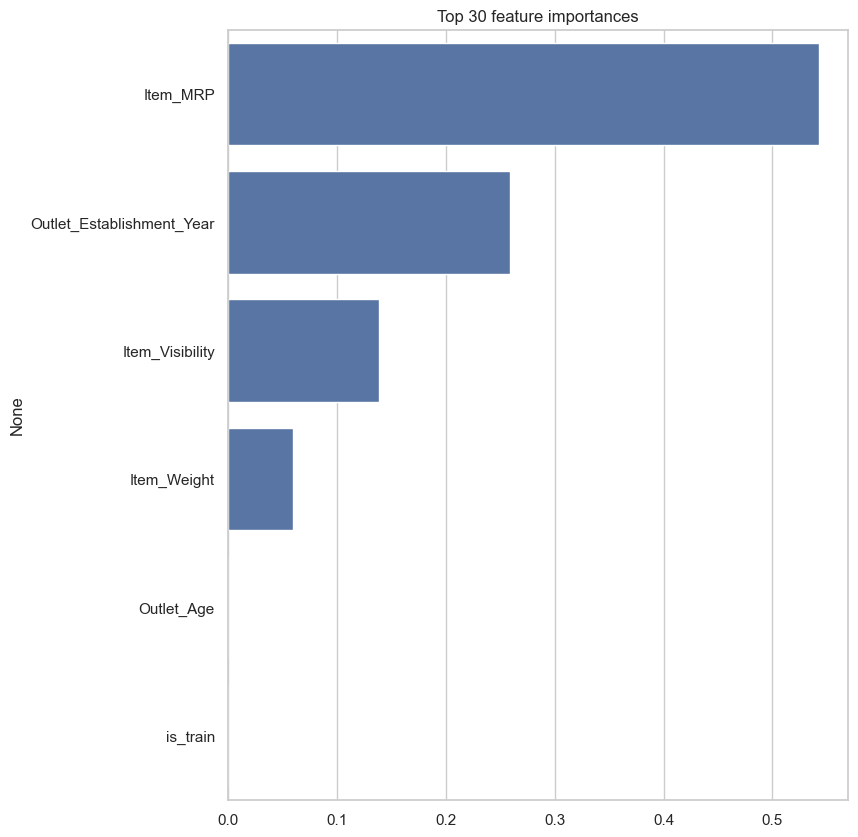

In [25]:
# Feature importance if RandomForest or XGBoost used
try:
    if hasattr(final_model, 'feature_importances_'):
        importances = final_model.feature_importances_
        feat_names = num_cols  # our ordered numeric+dummies columns
        fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(30)
        plt.figure(figsize=(8,10))
        sns.barplot(x=fi.values, y=fi.index)
        plt.title('Top 30 feature importances')
        plt.show()
    else:
        print('Final model has no feature_importances_ attribute.')
except Exception as e:
    print('Could not compute feature importances:', e)

### Next steps & suggestions
- Hyperparameter tuning with GridSearchCV/RandomizedSearchCV
- Use cross-validation (KFold) for more robust metrics
- Add SHAP explainability for model interpretation
- Deploy a small Streamlit app showing predictions

---
*Notebook generated programmatically; run cells in order.*